# Análise Base Diabetes (Pima Indians)

Este notebook importa a base original direto do Kaggle para prepararmos para os treinamentos.

In [1]:
%pip install kagglehub pandas
%pip install matplotlib
%pip install imbalanced-learn
%pip install seaborn

  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.23-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached charset_normalizer-3.4.7-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
Using cached kagglehub-1.0.1-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.23-py3-none-any.whl (217 kB)
Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl (437 kB)
Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl (154 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached charset_normalize

In [2]:
import kagglehub
import pandas as pd
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore') 
import matplotlib.pyplot as plt

#Preparando arquivo direto do kaggle
path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
dataset_path = os.path.join(path, csv_file)
print(f"Encontrado CSV em: {dataset_path}")

#Configuracoes do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#Configuracoes do matplotlib
plt.rcParams['figure.figsize'] = (15, 10)


import seaborn as sns

c:\Users\soulo\workspace\techchallenge1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\soulo\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1
Encontrado CSV em: C:\Users\soulo\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1\diabetes.csv


In [3]:
#Analise inicial do formato do dataset
df = pd.read_csv(dataset_path)
print("Formato do dataset:", df.shape)
df.head()



Formato do dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Como a base apresenta forte desbalanceamento no alvo (*Outcome*), exigiremos técnicas de pré-processamento  antes da etapa de modelagem.

## Análise Exploratória dos Dados
Nesta etapa, vamos investigar as distribuições, correlações e o comportamento geral das variáveis no dataset.

In [6]:
df.groupby("Outcome").describe().T

Outcome                                  0           1
Pregnancies              count  500.000000  268.000000
                         mean     3.298000    4.865672
                         std      3.017185    3.741239
                         min      0.000000    0.000000
                         25%      1.000000    1.750000
                         50%      2.000000    4.000000
                         75%      5.000000    8.000000
                         max     13.000000   17.000000
Glucose                  count  500.000000  268.000000
                         mean   109.980000  141.257463
                         std     26.141200   31.939622
                         min      0.000000    0.000000
                         25%     93.000000  119.000000
                         50%    107.000000  140.000000
                         75%    125.000000  167.000000
                         max    197.000000  199.000000
BloodPressure            count  500.000000  268.000000
                         mean    68.184000   70.824627
                         std     18.063075   21.491812
                         min      0.000000    0.000000
                         25%     62.000000   66.000000
                         50%     70.000000   74.000000
                         75%     78.000000   82.000000
                         max    122.000000  114.000000
SkinThickness            count  500.000000  268.000000
                         mean    19.664000   22.164179
                         std     14.889947   17.679711
                         min      0.000000    0.000000
                         25%      0.000000    0.000000
                         50%     21.000000   27.000000
                         75%     31.000000   36.000000
                         max     60.000000   99.000000
Insulin                  count  500.000000  268.000000
                         mean    68.792000  100.335821
                         std     98.865289  138.689125
                         min      0.000000    0.000000
                         25%      0.000000    0.000000
                         50%     39.000000    0.000000
                         75%    105.000000  167.250000
                         max    744.000000  846.000000
BMI                      count  500.000000  268.000000
                         mean    30.304200   35.142537
                         std      7.689855    7.262967
                         min      0.000000    0.000000
                         25%     25.400000   30.800000
                         50%     30.050000   34.250000
                         75%     35.300000   38.775000
                         max     57.300000   67.100000
DiabetesPedigreeFunction count  500.000000  268.000000
                         mean     0.429734    0.550500
                         std      0.299085    0.372354
                         min      0.078000    0.088000
                         25%      0.229750    0.262500
                         50%      0.336000    0.449000
                         75%      0.561750    0.728000
                         max      2.329000    2.420000
Age                      count  500.000000  268.000000
                         mean    31.190000   37.067164
                         std     11.667655   10.968254
                         min     21.000000   21.000000
                         25%     23.000000   28.000000
                         50%     27.000000   36.000000
                         75%     37.000000   44.000000
                         max     81.000000   70.000000

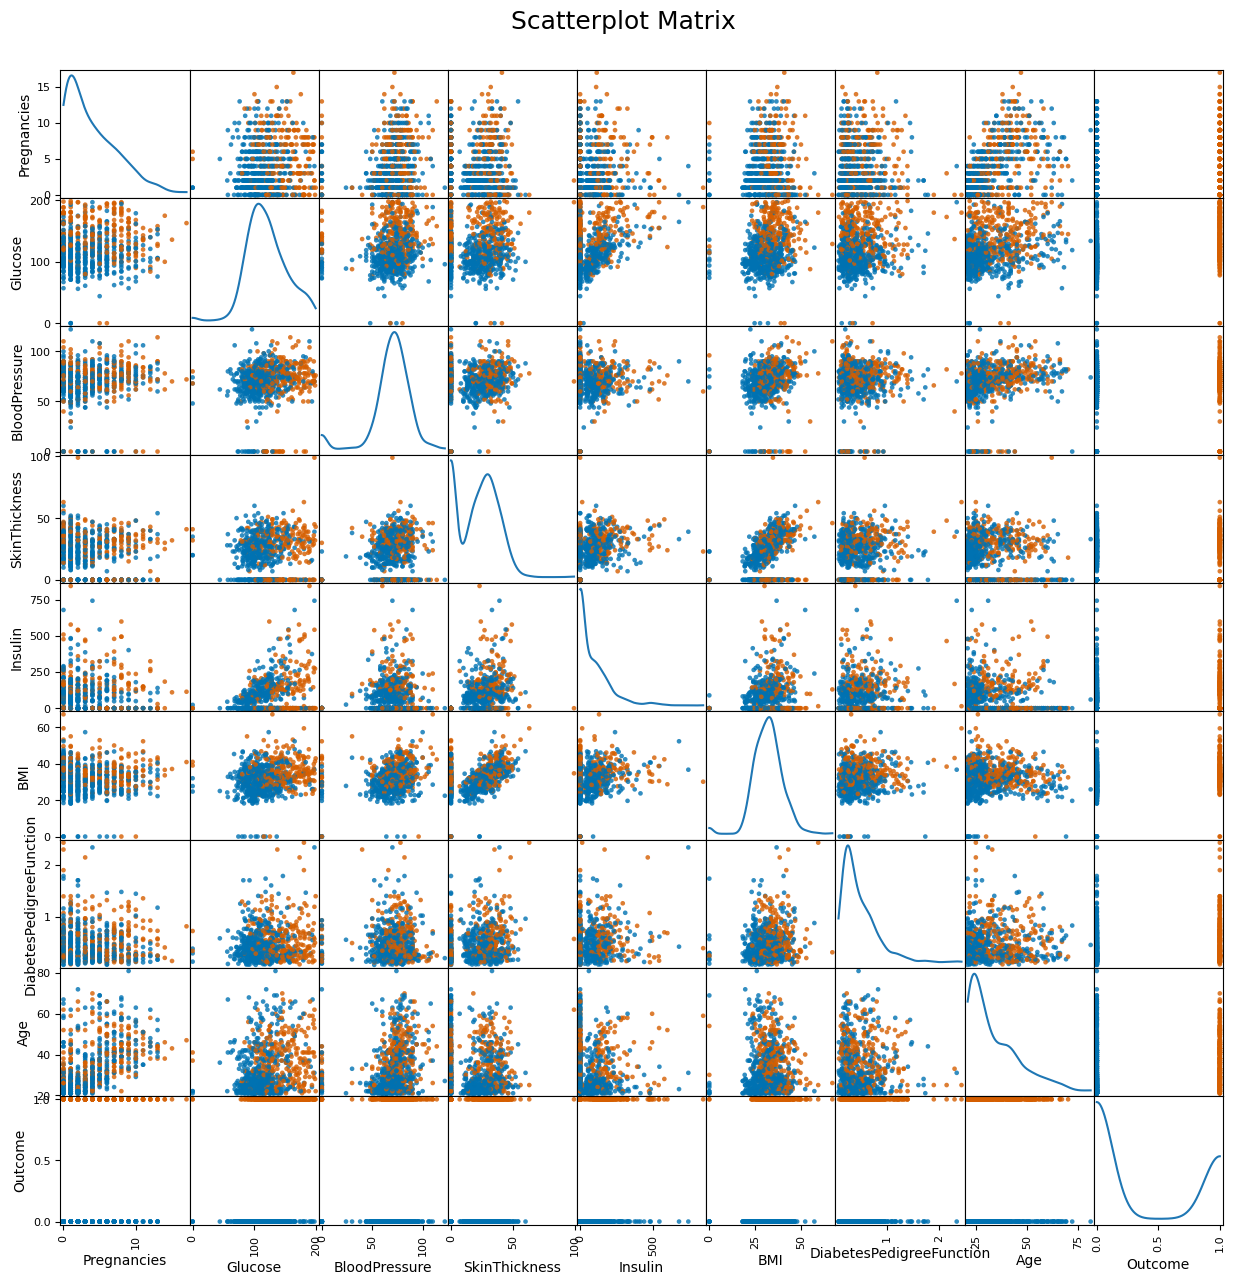

In [7]:

fig, ax = plt.subplots(figsize=(15, 15))

pd.plotting.scatter_matrix(
    df, 
    alpha=0.8,      
    figsize=(15, 15), 
    diagonal='kde',

    color=df['Outcome'].map({0: '#0072B2', 1: '#D55E00'}), 
    ax=ax,
    s=45             
)
plt.suptitle("Scatterplot Matrix", y=0.92, fontsize=18)
plt.show()

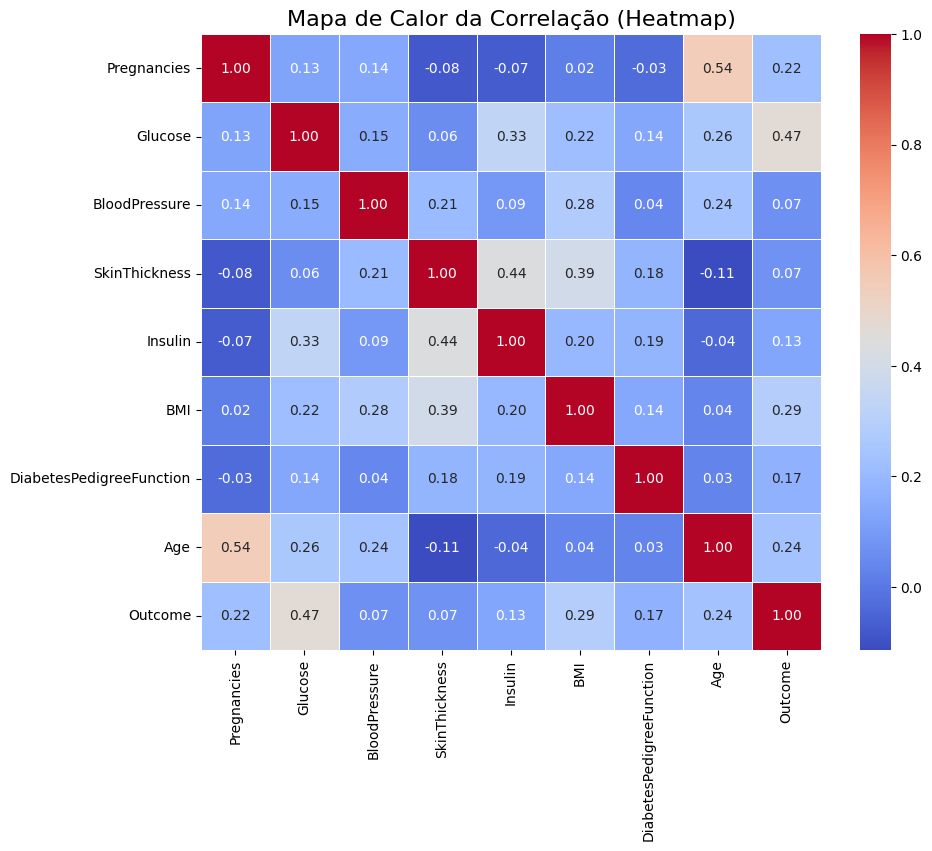

In [8]:

plt.figure(figsize=(10, 8))
matriz_correlacao = df.corr()
# Desenhando o Mapa de Calor
sns.heatmap(
    matriz_correlacao, 
    annot=True,       
    cmap='coolwarm',   # Azul profundo = Negativo | Branco = Zero | Vermelho forte = Positivo
    fmt=".2f",        
    linewidths=0.5
)
plt.title("Mapa de Calor da Correlação (Heatmap)", fontsize=16)
plt.show()

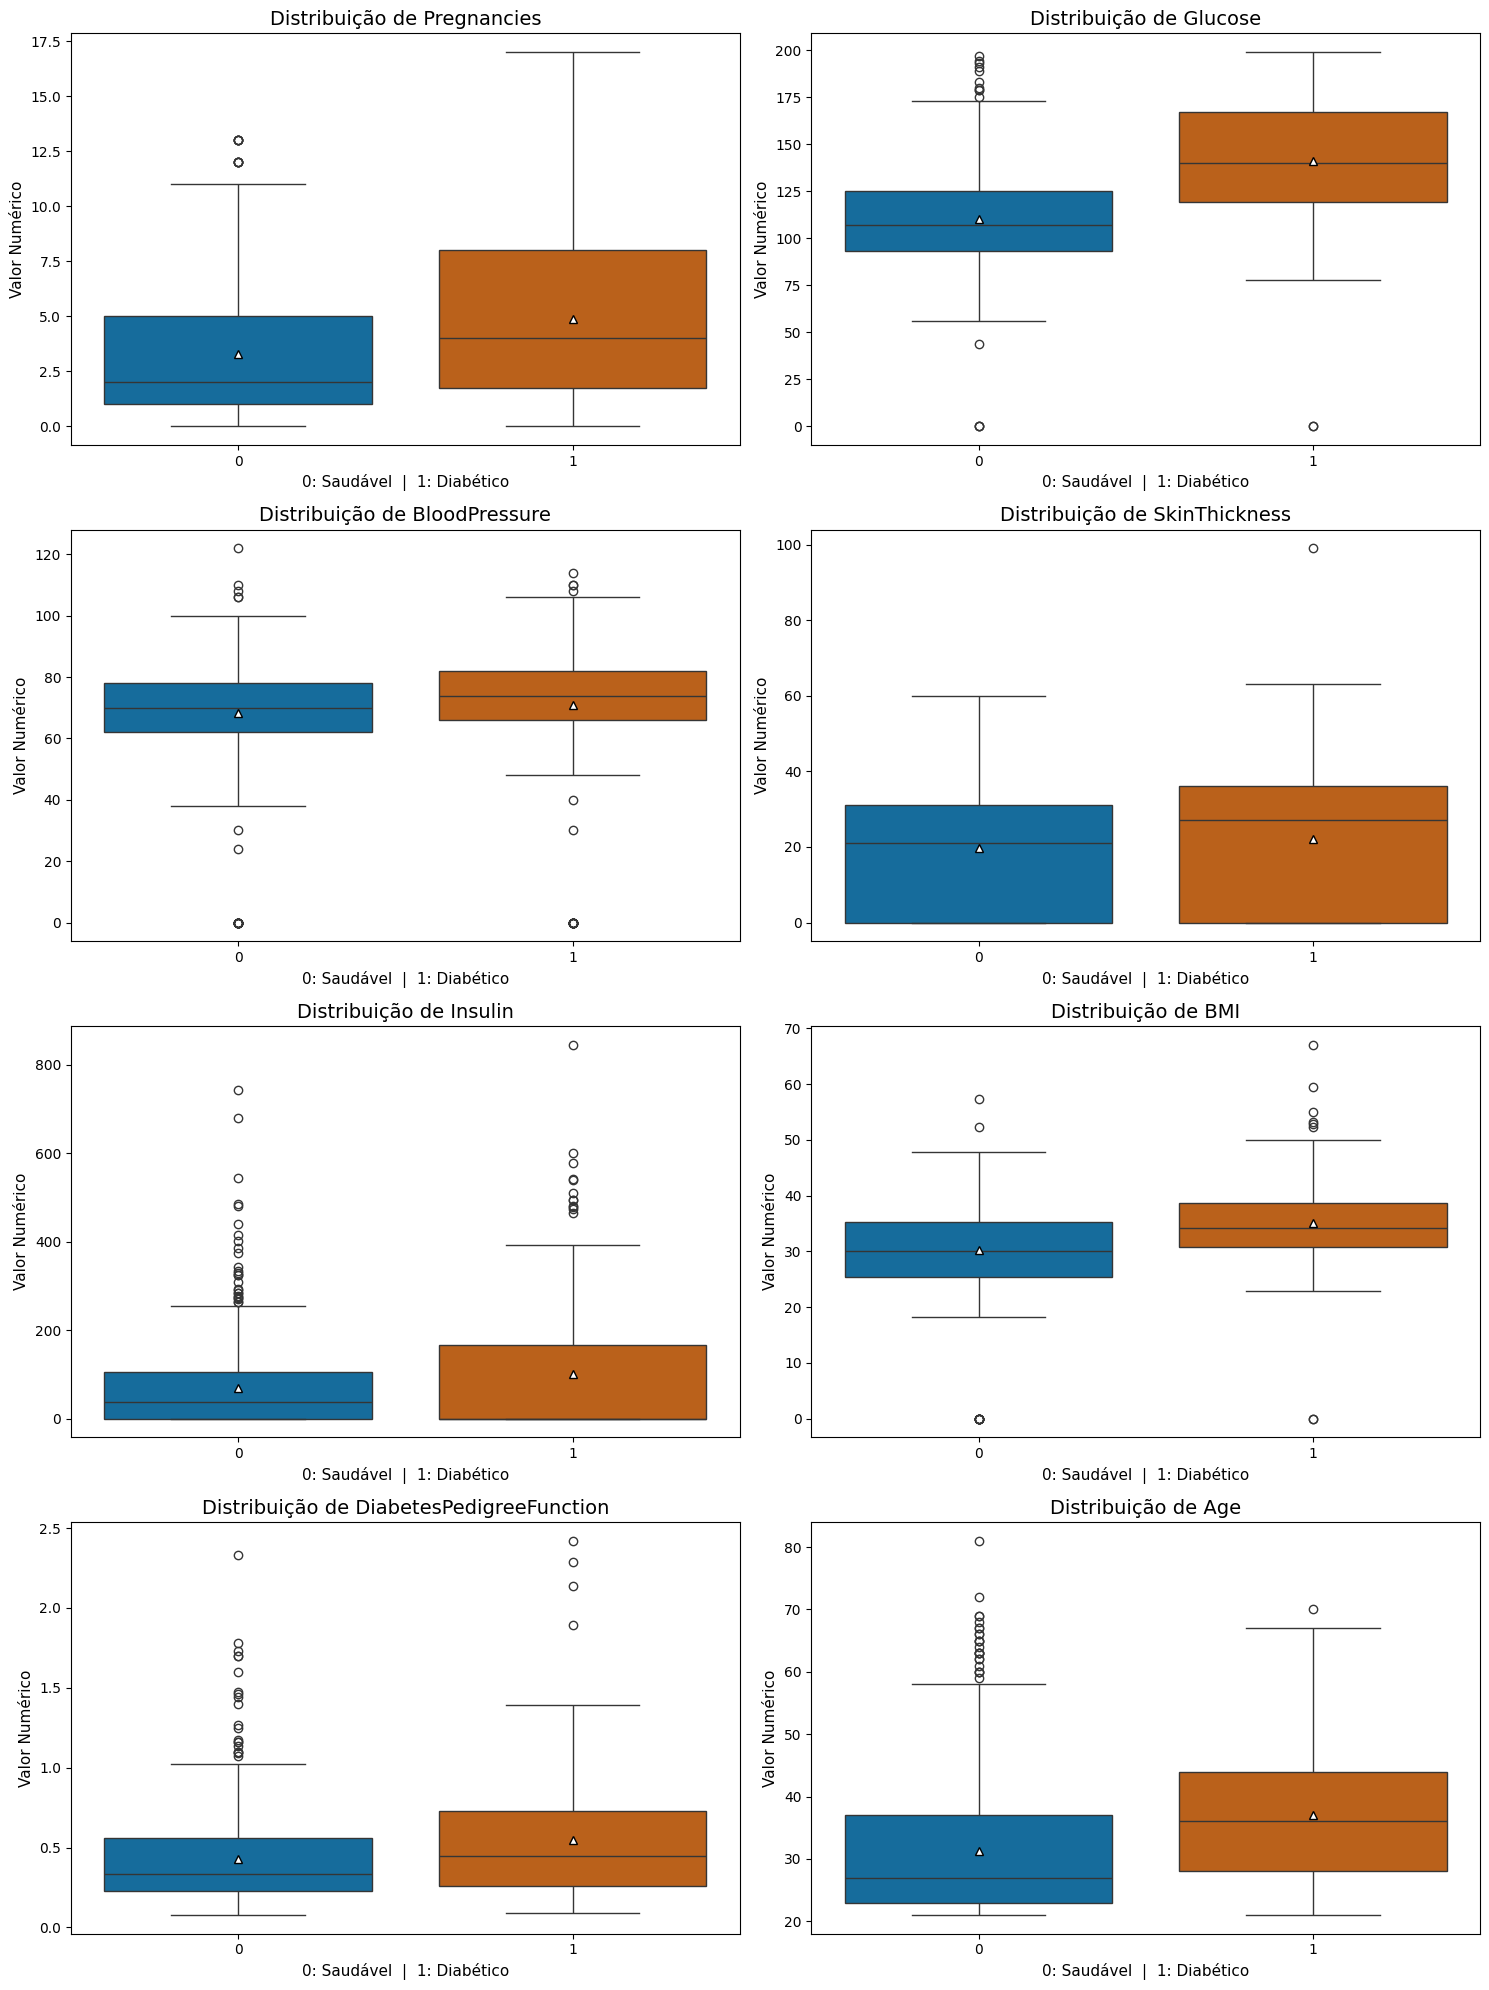

In [9]:

todas_as_colunas = df.columns.drop('Outcome')

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

axes = axes.flatten()
for i, coluna in enumerate(todas_as_colunas):
    sns.boxplot(
        data=df, 
        x='Outcome', 
        y=coluna, 
        palette=["#0072B2", "#D55E00"], 
        showmeans=True, 
        meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black"},
        ax=axes[i]
    )
    axes[i].set_title(f'Distribuição de {coluna}', fontsize=14)
    axes[i].set_xlabel('0: Saudável  |  1: Diabético', fontsize=11)
    axes[i].set_ylabel('Valor Numérico', fontsize=11)
plt.tight_layout()
plt.show()


### Variáveis Preditivas Principais (Correlação com o Target `Outcome`)
A análise das métricas evidencia diferentes níveis de potencial preditivo entre as variáveis disponíveis:
* **Preditores Fortes:** As variáveis `Glucose` (**0.46**) e `BMI` (**0.29**) apresentam os maiores índices de correlação positiva com a prevalência da doença, configurando-se como os principais descritores para a construção do modelo.
* **Preditores Secundários:** Em um patamar secundário de relevância preditiva figuram as métricas contextuais do paciente, representadas pelas variáveis `Age` (**0.23**), `Pregnancies` (**0.22**) e `DiabetesPedigreeFunction` (**0.17**).
* **Preditores de Baixo Impacto:** Variáveis de natureza fisiológica contínua, especificamente `SkinThickness` (**0.07**) e `BloodPressure` (**0.06**), demonstram correlação quase nula com o desfecho. 

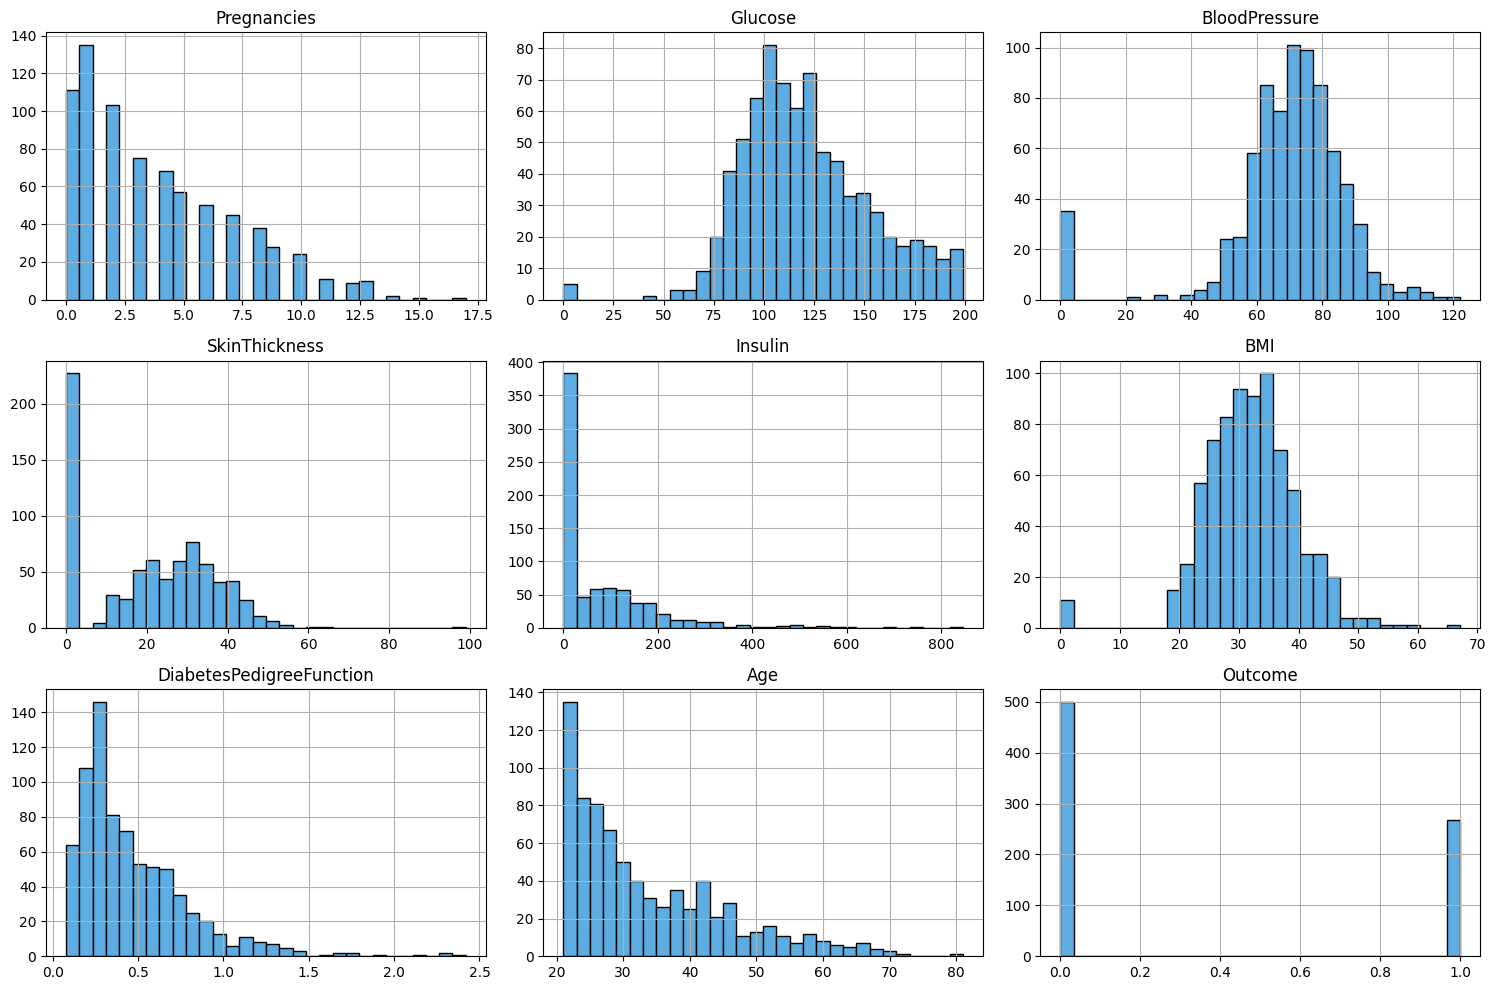

In [10]:
df.hist(bins=30, color='#5dade2', edgecolor='black')
# Exibe na tela
plt.tight_layout()
plt.show()

## Detectando outliers 

In [11]:
# Colunas biológicas que não podem ter valor zero
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Soma a quantidade de zeros
zero_counts = (df[cols_to_check] == 0).sum()
# Calcula a porcentagem perante o total de linhas (len(df))
zero_percentages = round((zero_counts / len(df)) * 100, 2)
# Coloca num DataFrame pra visualizar bonito
zeros_info = pd.DataFrame({'Zeros (Qtd)': zero_counts, 'Percentual (%)': zero_percentages})
zeros_info.sort_values(by='Percentual (%)', ascending=False)

,Zeros (Qtd),Percentual (%)
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


## Estratégia de Pré-Processamento
Com base no que vimos nessa análise exploratória, definimos a seguinte rota antes de ir pra parte de modelagem:
* **Lidando com os zeros:** 
Tem bastante dado na base que tá com valor `0` onde é impossível (tipo pressão e IMC). Se a gente apagar essas linhas agora, vamos jogar fora quase metade do dataset. A ideia então é usar o `SimpleImputer` pra preencher esses buracos com a mediana. Só precisaremos lembrar de calcular essa mediana estritamente nos dados de Treino lá na frente, pra evitar *data leakage* com a base de teste.
* **Sem necessidade de PCA:**
Nossa base é super pequena, com só 8 colunas preditoras. Rodar redução de dimensionalidade (PCA) não faz sentido aqui. Se fizéssemos isso, a gente perderia a capacidade de entender qual coluna exata (como a Glicose) puxa mais o diagnóstico da doença, sem ganhar quase nada de performance em troca.

In [12]:

#Preparacao das bases de treino e testes
X_completo = df.drop(columns=['Outcome'])
y_completo = df['Outcome']
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X_completo, y_completo, test_size=0.3, stratify=y_completo, random_state=42)

colunas_criticas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

imputador_70_30 = KNNImputer(missing_values=0, n_neighbors=5)
X_train_70[colunas_criticas] = imputador_70_30.fit_transform(X_train_70[colunas_criticas])
X_test_30[colunas_criticas] = imputador_70_30.transform(X_test_30[colunas_criticas])
# 3. SMOTE PARA 70/30
smote_70 = SMOTE(random_state=42)
X_train_70_smote, y_train_70_smote = smote_70.fit_resample(X_train_70, y_train_70)
rf_70_30 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5,
    max_features='log2',
    min_samples_split=10, 
    random_state=42
)
rf_70_30.fit(X_train_70_smote, y_train_70_smote)

y_pred_30 = rf_70_30.predict(X_test_30)

In [13]:
# 1. Instanciando o modelo idêntico ao original
rf_sem_smote = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    max_features='log2', 
    min_samples_split=10, 
    random_state=42
)
# 2. Treinando na base DESBALANCEADA (Sem o sufixo _smote)
rf_sem_smote.fit(X_train_70, y_train_70)
# 3. Fazendo as previsões
y_pred_sem_smote = rf_sem_smote.predict(X_test_30)



In [14]:
# 1. Separando em 80% Treino e 20% Validação
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X_completo, y_completo, 
    test_size=0.2,            # <-- Alterado para 20%
    stratify=y_completo, 
    random_state=42
)
# 2. Imputando Zeros (Preenchendo usando os vizinhos apenas dos 80%)
imputador_80_20 = KNNImputer(missing_values=0, n_neighbors=5)
X_train_80[colunas_criticas] = imputador_80_20.fit_transform(X_train_80[colunas_criticas])
X_test_20[colunas_criticas] = imputador_80_20.transform(X_test_20[colunas_criticas])
# 3. Aplicando SMOTE apenas no Treino de 80%
smote_80 = SMOTE(random_state=42)
X_train_80_smote, y_train_80_smote = smote_80.fit_resample(X_train_80, y_train_80)
# 4. Treinando o Random Forest Otimizado
rf_80_20 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    max_features='log2', 
    min_samples_split=10, 
    random_state=42
)
rf_80_20.fit(X_train_80_smote, y_train_80_smote)
# 5. O Grande Teste nos 20% Intocados
y_pred_20 = rf_80_20.predict(X_test_20)



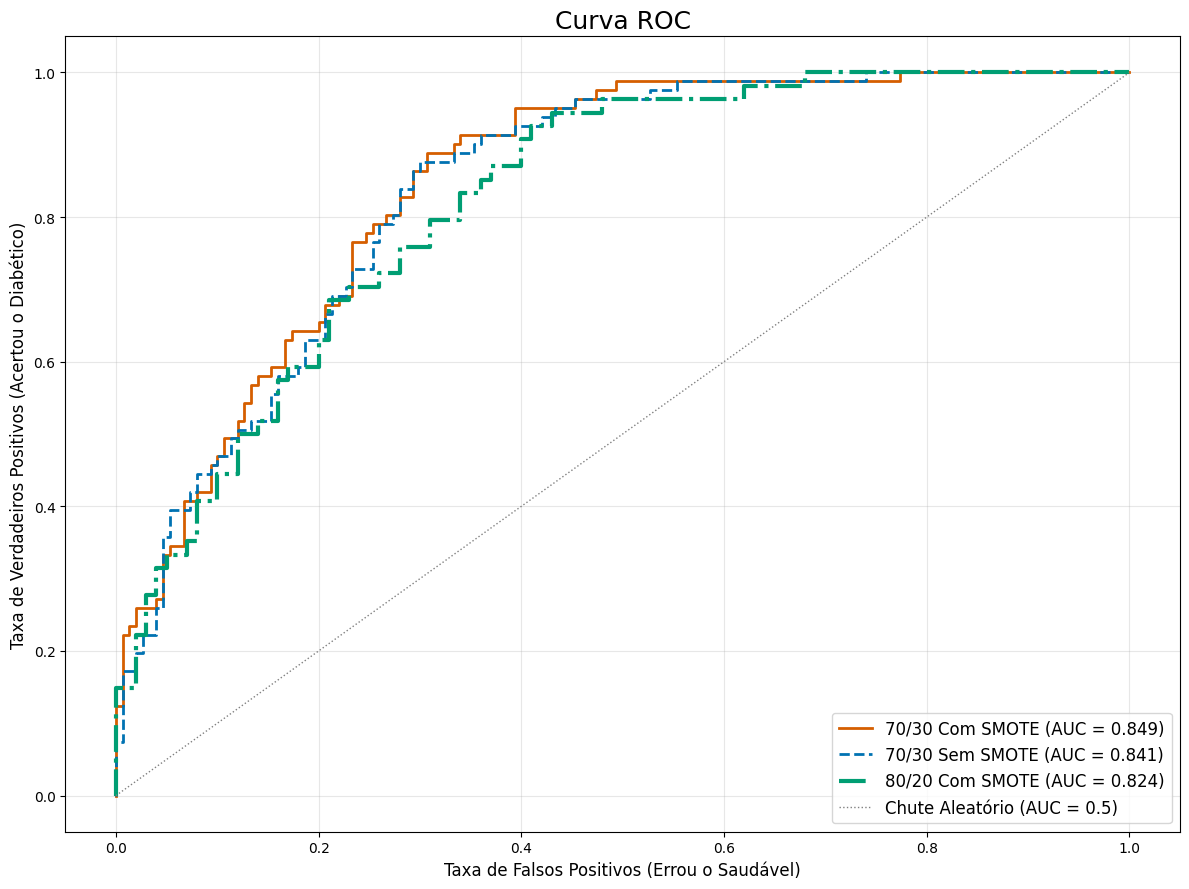

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# --- PREVISÕES DAS 3 FLORESTAS ---
# 1. Pipeline 70/30 Com SMOTE
y_prob_smote = rf_70_30.predict_proba(X_test_30)[:, 1]
auc_smote = roc_auc_score(y_test_30, y_prob_smote)
fpr_smote, tpr_smote, _ = roc_curve(y_test_30, y_prob_smote)
# 2. Pipeline 70/30 Sem SMOTE
y_prob_sem_smote = rf_sem_smote.predict_proba(X_test_30)[:, 1]
auc_sem_smote = roc_auc_score(y_test_30, y_prob_sem_smote)
fpr_sem, tpr_sem, _ = roc_curve(y_test_30, y_prob_sem_smote)

y_prob_80_20 = rf_80_20.predict_proba(X_test_20)[:, 1]
auc_80_20 = roc_auc_score(y_test_20, y_prob_80_20)
fpr_80_20, tpr_80_20, _ = roc_curve(y_test_20, y_prob_80_20)

plt.figure(figsize=(12, 9))

plt.plot(fpr_smote, tpr_smote, color='#D55E00', lw=2, 
         label=f'70/30 Com SMOTE (AUC = {auc_smote:.3f})')

plt.plot(fpr_sem, tpr_sem, color='#0072B2', lw=2, linestyle='--', 
         label=f'70/30 Sem SMOTE (AUC = {auc_sem_smote:.3f})')
plt.plot(fpr_80_20, tpr_80_20, color='#009E73', lw=3, linestyle='-.', 
         label=f'80/20 Com SMOTE (AUC = {auc_80_20:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Chute Aleatório (AUC = 0.5)')
# Perfumaria do Gráfico
plt.title('Curva ROC', fontsize=18)
plt.xlabel('Taxa de Falsos Positivos (Errou o Saudável)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Acertou o Diabético)', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print("########### CLASSIFICATION REPORT 70% TREINO COM SMOTE")
print(classification_report(y_test_30, y_pred_30))
print("########### CLASSIFICATION REPORT 70% TREINO SEM SMOTE")
print(classification_report(y_test_30, y_pred_sem_smote))
print("########### CLASSIFICATION REPORT 80% TREINO COM SMOTE")
print(classification_report(y_test_20, y_pred_20))

########### CLASSIFICATION REPORT 70% TREINO COM SMOTE
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       150
           1       0.63      0.77      0.69        81

    accuracy                           0.76       231
   macro avg       0.74      0.76      0.75       231
weighted avg       0.78      0.76      0.77       231

########### CLASSIFICATION REPORT 70% TREINO SEM SMOTE
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       150
           1       0.65      0.56      0.60        81

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.70       231
weighted avg       0.73      0.74      0.73       231

########### CLASSIFICATION REPORT 80% TREINO COM SMOTE
              precision    recall  f1-score   support

           0       0.86      0.69      0.77       100
           1       0.58      0.80      0.67        54

    accuracy     

In [17]:
from sklearn.tree import DecisionTreeClassifier

# ========================================================
# 1. DECISION TREE (A Árvore Solitária)
# ========================================================
# Usamos a mesma profundidade (max_depth=5) para ser justo
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_70_smote, y_train_70_smote)
y_pred_dt = dt_model.predict(X_test_30)
print("🌲 RELATÓRIO: DECISION TREE (70/30 Com SMOTE)")
print(classification_report(y_test_30, y_pred_dt))
print("-" * 55)


🌲 RELATÓRIO: DECISION TREE (70/30 Com SMOTE)
              precision    recall  f1-score   support

           0       0.84      0.72      0.78       150
           1       0.59      0.75      0.66        81

    accuracy                           0.73       231
   macro avg       0.72      0.74      0.72       231
weighted avg       0.76      0.73      0.74       231

-------------------------------------------------------


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Treina o padronizador e já aplica na base de treino
X_train_70_knn = scaler.fit_transform(X_train_70_smote)
# Apenas aplica (sem treinar) na base de teste para evitar vazamento
X_test_30_knn = scaler.transform(X_test_30)
# Instanciando o KNN pedindo para olhar os 5 vizinhos mais próximos
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train_70_knn, y_train_70_smote)
y_pred_knn = knn_model.predict(X_test_30_knn)
print("🏘️ RELATÓRIO: KNN NORMALIZADO (70/30 Com SMOTE)")
print(classification_report(y_test_30, y_pred_knn))

🏘️ RELATÓRIO: KNN NORMALIZADO (70/30 Com SMOTE)
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       150
           1       0.59      0.72      0.65        81

    accuracy                           0.73       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.73      0.73       231

